# Dynamic Heterogeneity in Speckle Fluctuations

**Author:** Ahmad I. Us Saleheen  
**Platform:** Python 3.9+ | scikit-learn | scikit-beam | SciPy | statsmodels | sklearn

---

## Summary

X-ray Photon Correlation Spectroscopy (XPCS) provides a window into temporal fluctuations. Across timescales ranging from milliseconds to hundreds of seconds, XPCS probes domain dynamics in magnetic and quantum materials. In coherent scattering experiments, speckle patterns arise due to the  interference of coherently scattered X-rays, whose relative phase shifts encode the domain morphology of the sample. Consequently, fluctuaions in speckle patterns represent the domain dynamics in the system. Usually, the dynamics at a given length scale is calculated by averaging the intensity autocorrelation function $g_2(\tau)$ azimuthally across a static $q$-ring. However, in many systems, the individual speckles  within that ring often exhibit diverse spatio-temporal behavior. Proving such dynamic heterogeneity requires segmenting and tracking individual speckles. 

This project implements an end-to-end unsupervised machine learning and signal processing pipeline to detect, isolate, and cluster speckles by their dynamical signatures. The raw data consists of continuous photon event streams from an MCP/Timepix3 detector recorded during a Coherent Resonant Soft X-ray Scattering (CRSXS) experiment on an amorphous Fe/Ge system at ALS beamline 7.0.1.1 (COSMIC). Key highlights include:

* **Scale:** Ingests and aggregates $\approx 10^8$ raw Timepix3 photon event timestamps at single-photon resolution.
* **Segmentation:** Isolates coherent speckles from diffuse background scatter using an unsupervised consensus ensemble (1D GMM, K-Means) and local spatial contrast filters.
* **Statistical Rigor:** Validates genuine physical dynamics using a 200-iteration permutation bootstrap hypothesis test (95% CI).
* **Heterogeneity Discovery:** Identifies distinct coexisting dynamical regimes via Gaussian Mixture Models (BIC-selected) and extracts physical relaxation mechanics using cluster-averaged KWW stretched exponential fits.



## **Pipeline Architecture** 

Raw Photon Timestamps (Timepix3: 1did, t)

**Step 0: Data Ingestion & Image Reconstruction**
- Collect photon timestamps at each pixel and sort chronologically via vectorized multi-key sort
- Calculate total number of photons at each pixel
- Reconstruct the 512 × 512 detector frame
- Isolate azimuthal q-ring (selects the characteristic scattering length scale of interest)

**Step 1: Feature Engineering & Speckle Segmentation**
- Bin photon counts at each pixel into 1 s discrete time bins (bin duration can be tuned)
- Calculate local contrast (mean count / local background mean, neighborhood radius r = 5 px) and local statistics
- Plot distributions of extracted features; local contrast provides the primary discriminating signal
- Unsupervised clustering & candidate segmentation:
    - 1D Gaussian Mixture Model (BIC model selection)
    - 2D K-Means Model (local contrast vs. peak-to-background ratio)
    - Hard contrast thresholding
    - Multi-model consensus voting
- Evaluate and select high-confidence speckle pixels for downstream analysis

**Step 2: Speckle Properties & Autocorrelation**
- Group speckle pixels into contiguous objects via 8-connected component labeling
- Size filtering based on beamline geometry: $8 \le \text{area} \le 50$ px  (removes noise hits and merged multi-speckle aggregates)
- Sum binned time series across member pixels within each speckle to maximize SNR prior to correlation
- Compute intensity autocorrelation g₂(τ) via FFT-accelerated statsmodels ACF
- 200-sample permutation bootstrap hypothesis test which shuffles time bins to establish an empirical 95% null CI, determining whether genuine temporal correlation exists above the experimental noise floor.
- Extract model-free crossing relaxation time $\tau_r$
- Classify and plot statistically significant dynamic speckles against non-dynamic baselines

**Step 3: Dynamic Clustering & Heterogeneity Mapping**
- 5D feature extraction per dynamic speckle: contrast $\beta$, mean $g_2$ decay, mean $g_2$ long baseline, decay slope, relaxation time $\tau_r$
- Feature standardization via StandardScaler
- Gaussian Mixture Model (GMM) clustering with BIC component selection
- DBSCAN cross-check to evaluate density boundaries and dynamical continuity
- Compute cluster-averaged g₂(τ) curves
- Generate detector spatial maps displaying cluster assignments, relaxation timescales, and assignment confidence

**Step 4: Fitting To Stretched Exponential Model**
- Average $g_2(\tau)$ curves across all speckles per cluster to suppress single-speckle noise
- Model: Kohlrausch-Williams-Watts (KWW) stretched exponential function: $g_2(\tau) = 1 + \beta\, exp[-2(\tau/\tau_r)^{\gamma}]$        
- Differential Evolution global optimization to locate robust initial parameter values
- Levenberg-Marquardt non-linear least squares refinement for parameter covariance estimation
- Extract physical parameters: relaxation time $\tau_r$, speckle contrast $\beta$, and stretching exponent $\gamma$
- Plot all the results, fitted curves, identify dynamic regimes, etc. 

In [1]:
#%load_ext autoreload
#%autoreload 2

In [2]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from skimage.util import img_as_float, img_as_ubyte
import skbeam.core.utils as utils
import numpy as np
import matplotlib.colors as mcolors
from tqdm import tqdm
import sys
import random
import inspect
import gc

In [3]:
from xpcs import data_reader_roi
from xpcs import speckle
from xpcs import speckle_g2
from xpcs import clustering
from xpcs import fitting

## **Step 0: Data Ingestion & Image Reconstruction**

* The following calcualtions were conducted using photon arrival data whose size is around 10 GB with 15 minutes experiment duration.
* The data file "sample_data_chunk.t3pa" within the 'data' directory contains 1_000_000 photon data with around 3s experiment duration. This can be run with this notebook for demonstration purposes.  
    

In [4]:
DATA_DIR =  os.path.join(os.getcwd(), 'data')
SAMPLE_FILENAME = 'sample_data_chunk.t3pa'
FULL_FILENAME = '250K_1800_warming2.t3pa'
folderpath = DATA_DIR
filename = SAMPLE_FILENAME
csize = 1_000_000 #247337166 #  # Dry-run slice
raw_data = data_reader_roi.file_read_chunk(folderpath, filename,  csize)


Loading data file '250K_1800_warming2.t3pa' with csize = 247,337,166...
Loading is complete. (247,337,166 rows loaded in 36.37 s)


In [5]:
raw_data.head(3)

,1did,t
0,230728,814
1,228704,900
2,228703,900


In [6]:
raw_data_sorted = raw_data.sort_values(by='t', ascending=True).reset_index(drop=True)


Process started, may take a few minutes......
Completed.


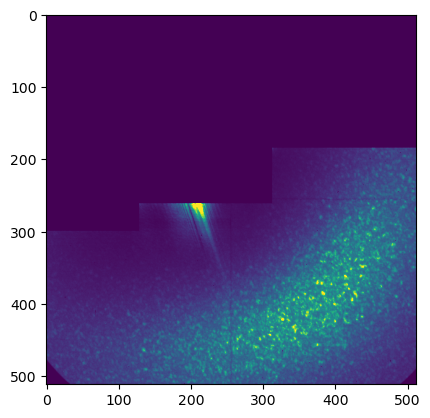

In [7]:
data_df, detector_image = data_reader_roi.imager_mask_remover_updated(raw_data_sorted, 0, 8000)


In [8]:
display(data_df.head(3))
print(f'data_df shape:{data_df.shape}')

,1did,PhNo,ts,x,y
0,300,726.0,"[3493196, 17416202, 21296648, 34077299, 397433...",300,0
1,301,725.0,"[6141862, 21296648, 29700320, 39743391, 446567...",301,0
2,302,703.0,"[6141862, 8227237, 29700320, 34001623, 3563869...",302,0


data_df shape:(262144, 5)


### Everything we need is in data_df. We can free up memory by deleting raw_data

In [9]:
del raw_data
del raw_data_sorted
_ = gc.collect()

### Isolate a q-ring. For demostration purposes, a large ring is chosen.

In [10]:

experimental_parameters = {'center_beam': (201,213),
                          'distance': 1,
                           'energy_ev': 706,
                          'rad_ini': 0.012,
                          'rad_fin': 0.017,
                          'agrid_ini': 0.3,
                          'agrid_fin': 1.35
                          }

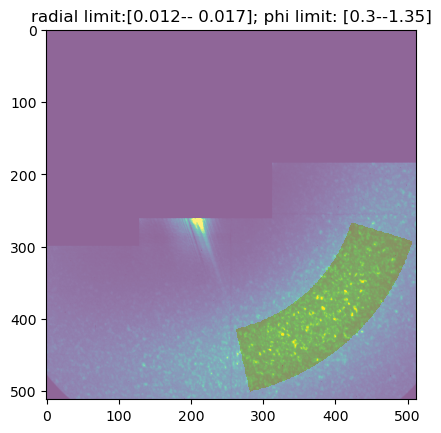

In [11]:
q_ring= data_reader_roi.q_roi_viewer_new(detector_image, vm1 = 800, vm2 = 8000, **experimental_parameters,)


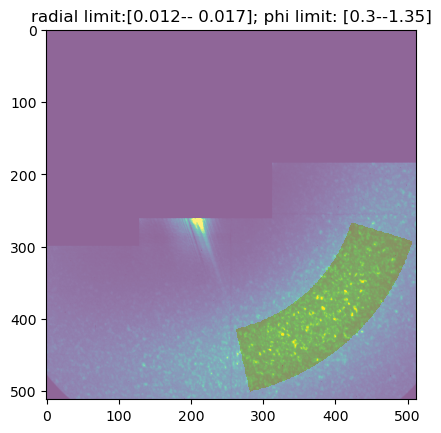

In [12]:
# Collect all the timestamps within the q-ring
q_ring_ts =data_reader_roi.timestamps_from_ring_movie(data_df, detector_image, vm1 = 800, vm2 = 8000, **experimental_parameters)

## **Step 1: Feature Engineering & Speckle Segmentation**

### Note: If using the sample data which is of ~3 second duration, change DT_NS = 1e7 to have 0.01s bins.  In this way, there would be enough data to calculate autocorrelation functions.

In [13]:
# ============================================================ #
# PARAMETERS For Data Binning                  #
# ============================================================ #
Q_RING_INDEX             = 1
DT_NS                    = 1e9 # Bin duration in nanosecond. 1e9 would create 1s bins; 1e8 will create 0.1 s bins, and so on
IMAGE_HEIGHT             = 512
IMAGE_WIDTH              = 512
LOCAL_RADIUS             = 5    # neighborhood radius for local contrast
INTENSITY_RANK_THRESHOLD = 0.85 # top 15% by intensity
LOCAL_CONTRAST_THRESHOLD = 1.15 # 15% brighter than local background
full_image               = None # replace with  detector image if desirable

In [14]:

# Bin timestamps ---
binned_series_list, bins, pixel_ids, n_bins = data_reader_roi.compute_binned_series(
        q_ring_ts,
        q_ring_index=Q_RING_INDEX,
        dt=DT_NS
    )

--- Binning photon timestamps ---
  Duration         : 858.99 seconds
  Number of bins   : 858
  Pixels to process: 25173
  Done. Binned series shape: (25173, 858)


In [15]:
# -Extract basic pixel level features ---
feature_df = speckle.extract_speckle_features(
        binned_series_list,
        pixel_ids,
        image_width=IMAGE_WIDTH
    )


--- Extracting pixel features ---
  Feature matrix shape: (25173, 9)
  Feature summary:
       mean_count   variance  fano_factor  max_count  zero_fraction         cv
count   25173.000  25173.000    25173.000  25173.000      25173.000  25173.000
mean        4.167      4.310        1.030     12.210          0.025      0.509
std         1.156      1.307        0.055      2.435          0.021      0.061
min         1.739      1.741        0.828      6.000          0.000      0.269
25%         3.372      3.415        0.992     11.000          0.009      0.468
50%         3.959      4.054        1.028     12.000          0.020      0.509
75%         4.712      4.901        1.065     13.000          0.035      0.550
max        13.346     14.710        1.399     33.000          0.196      0.785


In [16]:
 # --- Extract enhanced local contrast features ---
enhanced_df = speckle.extract_enhanced_features(
        feature_df,
        binned_series_list,
        image_height=IMAGE_HEIGHT,
        image_width=IMAGE_WIDTH,
        local_radius=LOCAL_RADIUS
    )

--- Building intensity image for local contrast features ---
--- Extracting enhanced features ---
  Enhanced feature matrix shape: (25173, 16)

  Local contrast statistics (key discriminating feature):
  Mean  : 1.056
  Std   : 0.278
  Min   : 0.545
  Max   : 5.013
  95th percentile: 1.598
  99th percentile: 2.032


In [17]:
display(enhanced_df.head(3))
print(f"enhanced_df shape: {enhanced_df.shape}")

,1did,x,y,mean_count,variance,fano_factor,max_count,zero_fraction,cv,local_bg,local_contrast,local_excess,local_std,peak_to_local_bg,acf_short_lag,intensity_rank
0,134046.0,414,261,4.130536,4.087958,0.989692,11.0,0.015152,0.489493,0.824009,5.012730,3.306527,1.365384,13.349364,-0.002525,0.568109
1,134558.0,414,262,3.776224,3.816844,1.010757,13.0,0.029138,0.517362,1.007003,3.749964,2.769221,1.462632,12.909599,-0.011027,0.422874
2,134559.0,415,262,3.344988,3.432769,1.026243,11.0,0.027972,0.553895,1.164027,2.873634,2.180961,1.554481,9.449949,-0.001548,0.239264


enhanced_df shape: (25173, 16)


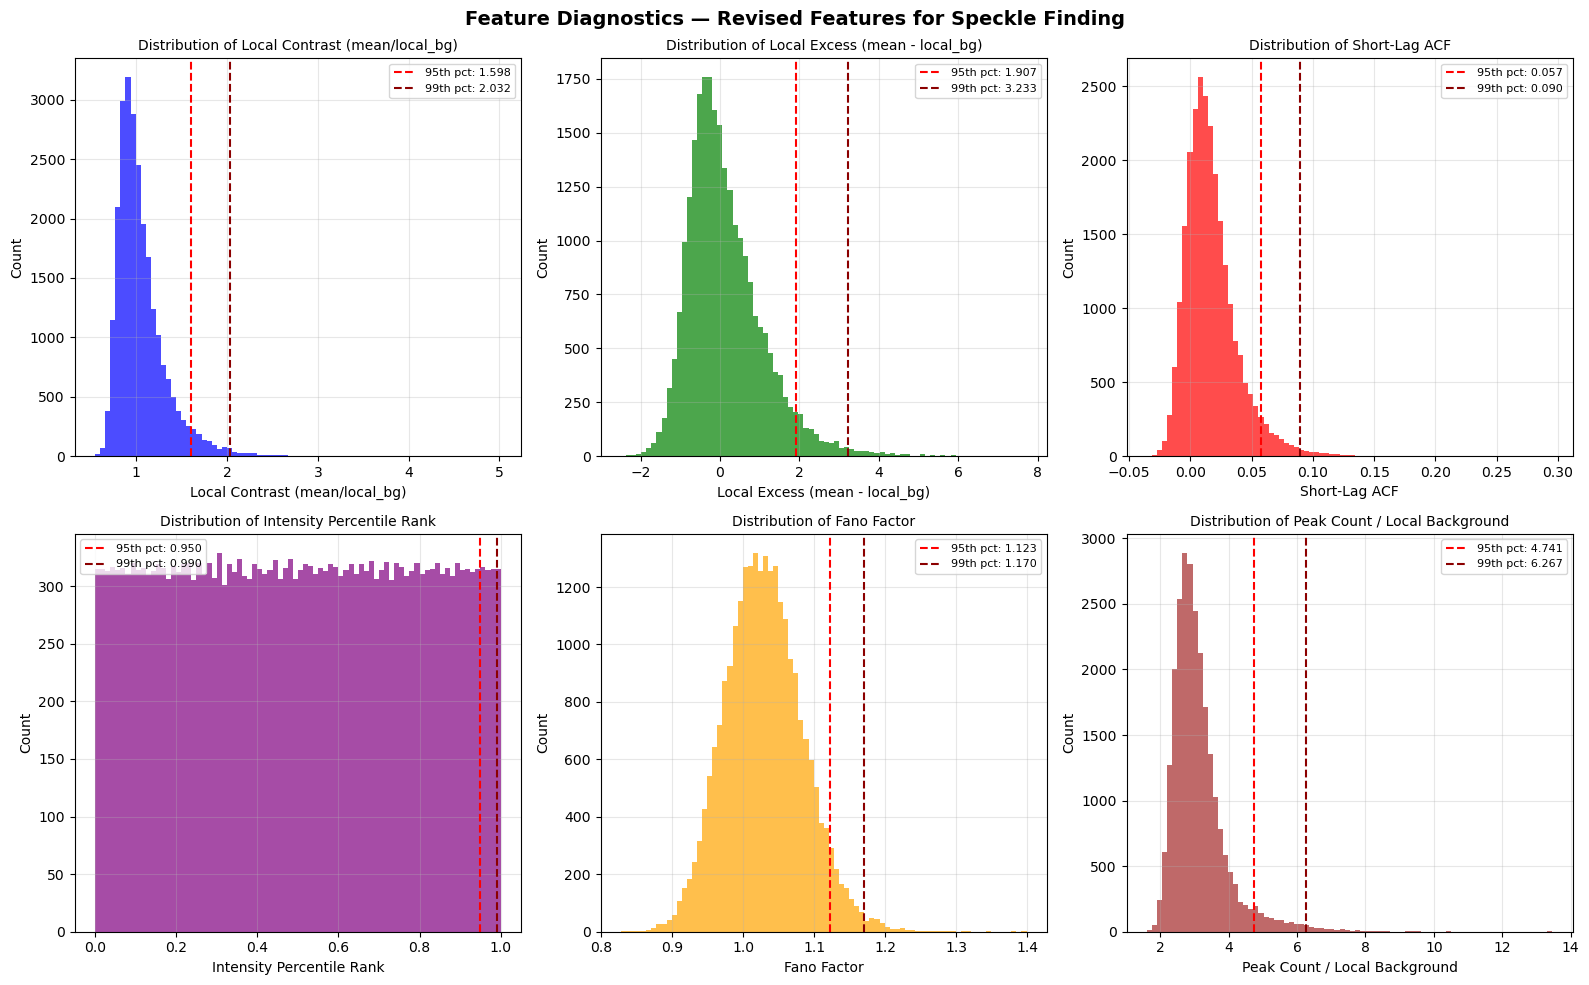

Diagnostic figure saved as 'step1_feature_diagnostics.png'

Examine the 'local_contrast' distribution carefully.
If speckles are present, there should be a tail above ~1.3 to 1.5.
Use this to guide the threshold or clustering approach.


In [18]:
speckle.plot_feature_diagnostics(enhanced_df)


In [19]:
  # ------------------------------------------------------------------ #
    #  Run streamlined ML speckle finding                         #
    # ------------------------------------------------------------------ #
enhanced_df, results = speckle.run_streamlined_speckle_finding_loose(
        enhanced_df,
        image_height=IMAGE_HEIGHT,
        image_width=IMAGE_WIDTH,
        local_contrast_threshold=LOCAL_CONTRAST_THRESHOLD
    )

STREAMLINED SPECKLE FINDING

Local contrast threshold : 1.15

[Approach 1] Hard threshold (local_contrast >= 1.15)
  Speckles found : 6562

[Approach 2] 1D GMM on local_contrast...
  n_components=2 : BIC = -2885.9
  n_components=3 : BIC = -4311.7
  Best n_components : 3 (lower BIC wins)
  Component means : [0.902 1.178 1.608]
  Speckle components : [0 2] (means: [1.178 1.608])
  Speckles found : 9077

[Approach 3] K-Means (k=2) on [local_contrast, peak_to_local_bg]...
  Silhouette score : 0.621
  Speckles found   : 4085

[Approach 4] DBSCAN on [local_contrast, peak_to_local_bg]...
  eps=0.2 → 8 clusters, 13 speckle candidates, 160 noise points
  eps=0.3 → 4 clusters, 8 speckle candidates, 77 noise points
  eps=0.5 → 3 clusters, 4 speckle candidates, 24 noise points
  eps=0.7 → 1 clusters, 25152 speckle candidates, 21 noise points
  eps=1.0 → 1 clusters, 25157 speckle candidates, 16 noise points
  Best eps : 0.2
  Speckles found : 13

SUMMARY
  Method                 N Speckles
  ------

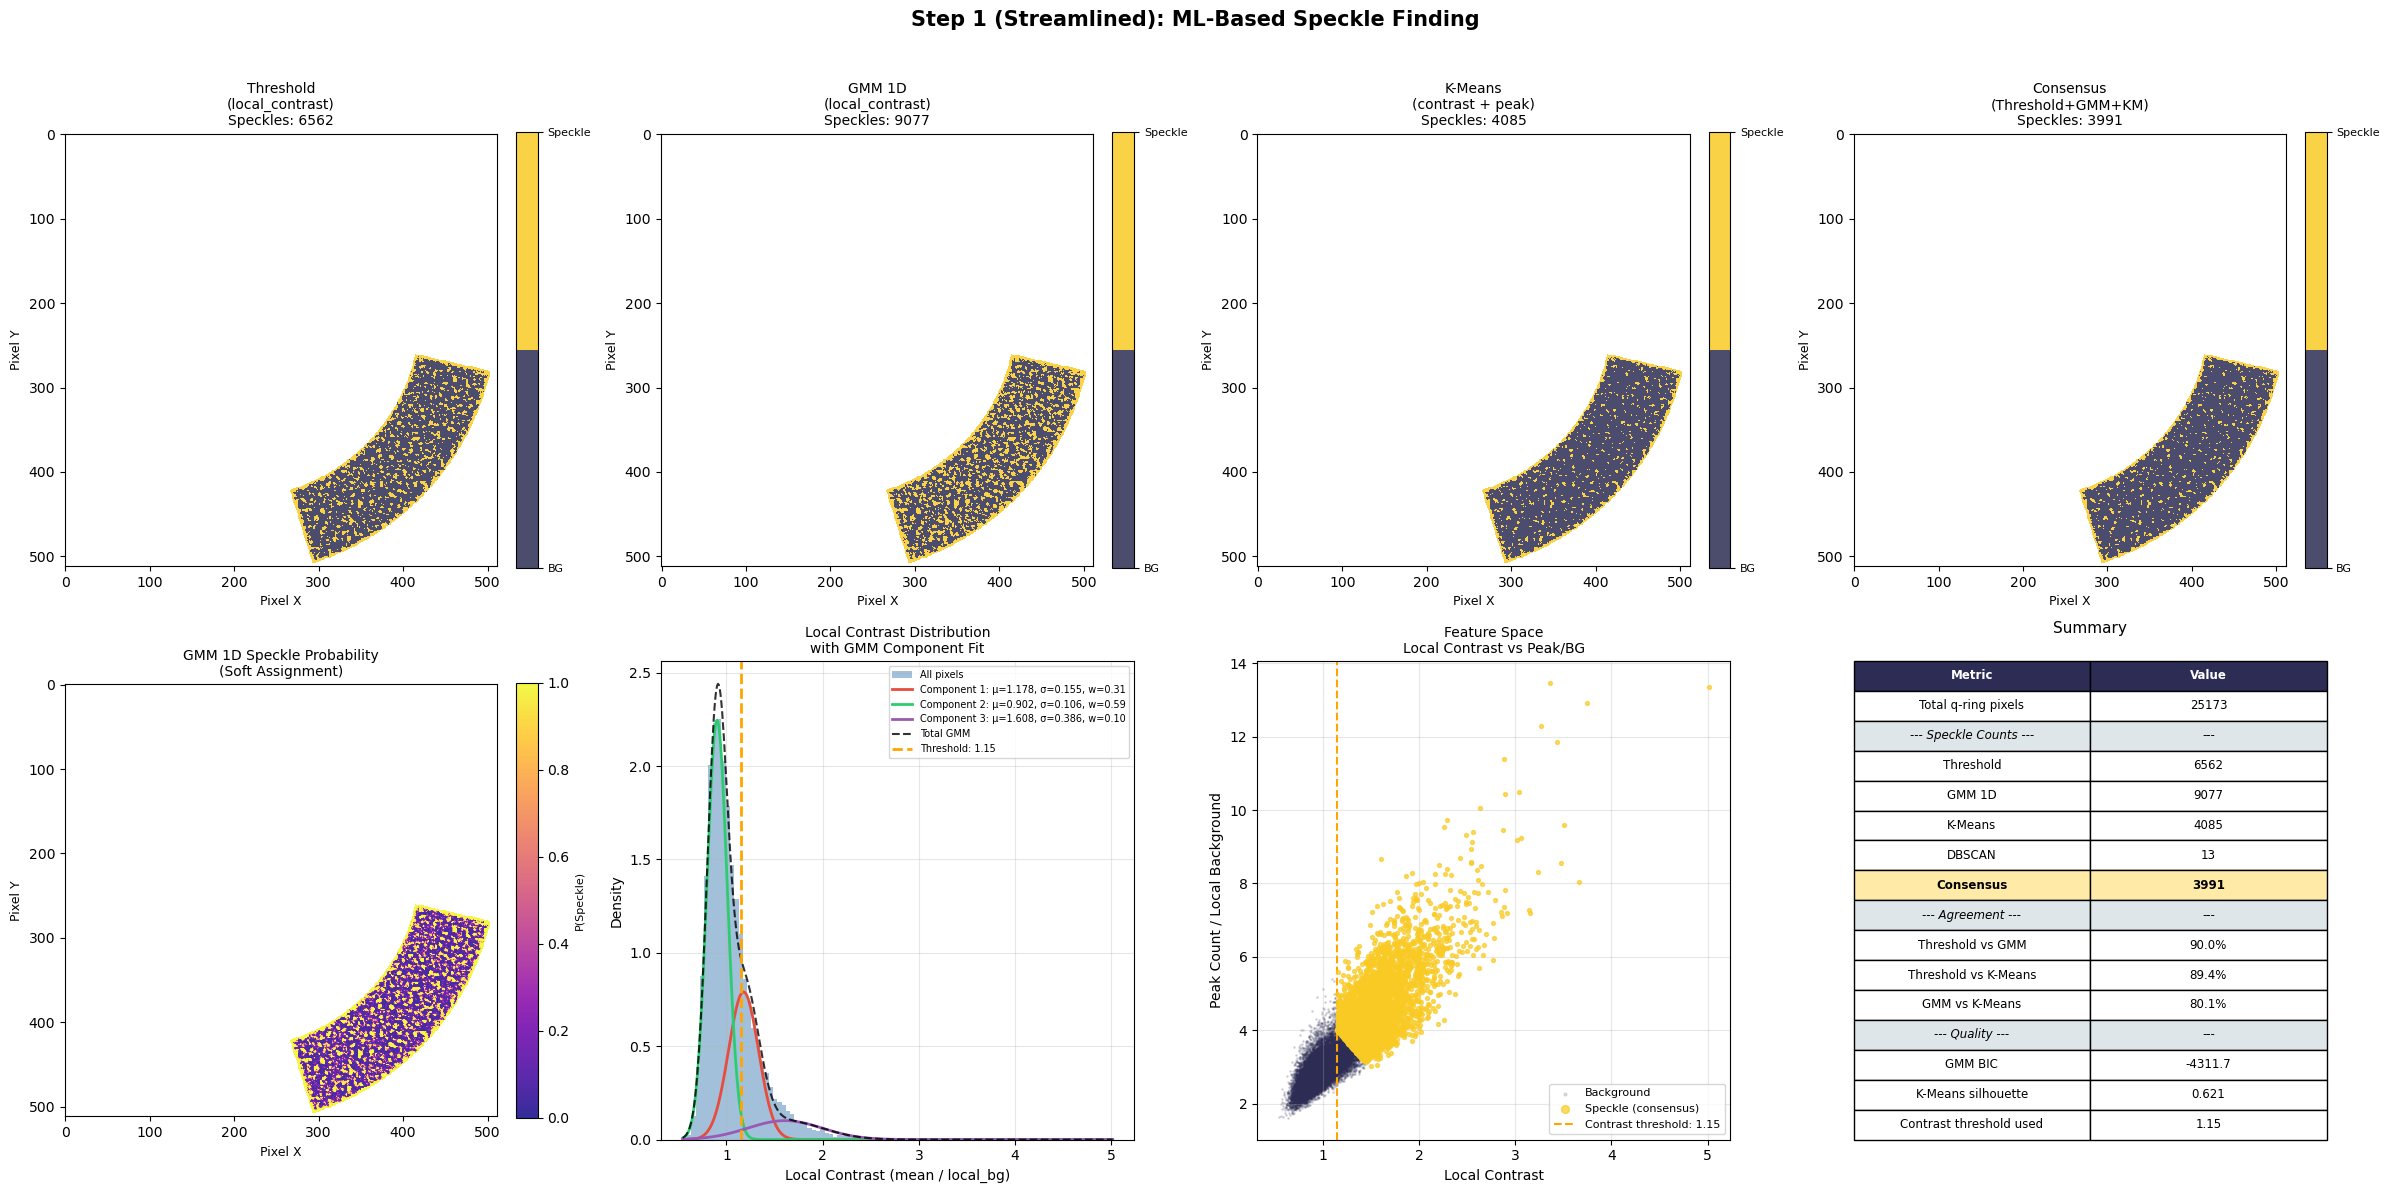


Figure saved as 'step1_streamlined_speckle_finding.png'


In [20]:
    # ------------------------------------------------------------------ #
    # Plot results from ML speckle finding                                              #
    # ------------------------------------------------------------------ #
speckle.plot_streamlined_results(
        enhanced_df,
        results,
        full_image=full_image,
        image_height=IMAGE_HEIGHT,
        image_width=IMAGE_WIDTH,
        local_contrast_threshold=LOCAL_CONTRAST_THRESHOLD
    )


--- Final speckle list (gmm1d) ---
  Speckle pixels          : 9077
  Mean local contrast     : 1.333
  Std local contrast      : 0.279
  Mean photon count       : 4.884
  X range                 : 266 to 502
  Y range                 : 261 to 508

Final speckle count          : 9077
OpenCV reference count       : 100
Ratio (ML / OpenCV)          : 90.77


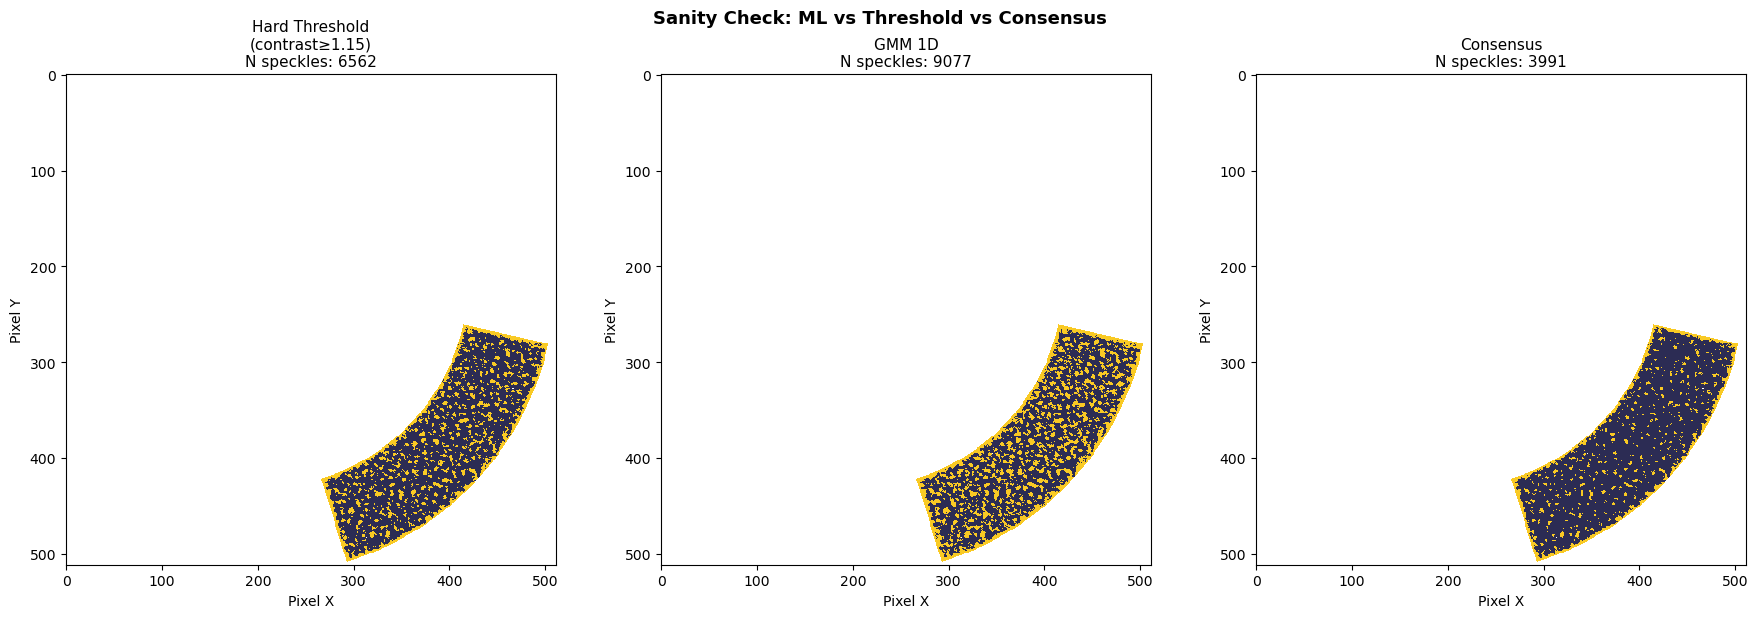


Step 1 complete.
  Speckle pixel list  → step1_speckle_pixels_final.csv
  Full pixel labels   → step1_all_pixels_with_labels.csv
  Proceeding to Step 2 with 9077 speckle pixels.


In [21]:
 # Choose final speckle list for Step 2 (next step)                       #
    # ------------------------------------------------------------------ #
    # Start with consensus. If the number looks too low compared to
    # OpenCV result, fall back to gmm1d or threshold.
    #speckle_df = get_final_speckle_list(enhanced_df, method='consensus')
speckle_df = speckle.get_final_speckle_list(enhanced_df, method='gmm1d')

    # Fallback logic based on speckle count
n_opencv_reference = 100  # replace with  known estimate of OpenCV speckle count
                              # serves as a reference for comparison

if len(speckle_df) < 20:
    print(f"\nConsensus gave only {len(speckle_df)} speckles.")
    print("Falling back to GMM1D...")
    speckle_df = get_final_speckle_list(enhanced_df, method='gmm1d')

if len(speckle_df) < 20:
    print(f"\nGMM1D gave only {len(speckle_df)} speckles.")
    print("Falling back to threshold...")
    speckle_df = speckle.get_final_speckle_list(enhanced_df, method='threshold')

print(f"\nFinal speckle count          : {len(speckle_df)}")
print(f"OpenCV reference count       : {n_opencv_reference}")
print(f"Ratio (ML / OpenCV)          : "
        f"{len(speckle_df) / n_opencv_reference:.2f}")

    # ------------------------------------------------------------------ #
    # Quick visual sanity check                                  #
    # Compare ML speckle map against  OpenCV result side by side      #
    # ------------------------------------------------------------------ #
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sanity Check: ML vs Threshold vs Consensus',
                 fontsize=13, fontweight='bold')

for ax, (method, label) in zip(axes, [
            ('threshold_label', f'Hard Threshold\n(contrast≥{LOCAL_CONTRAST_THRESHOLD})'),
            ('gmm1d_label',     'GMM 1D'),
            ('consensus_label', 'Consensus')]):

    cmap_2d = np.full((IMAGE_HEIGHT, IMAGE_WIDTH), np.nan)
    for _, row in enhanced_df.iterrows():
        cmap_2d[int(row['y']), int(row['x'])] = row[method]

    ax.imshow(cmap_2d,
                  cmap=mcolors.ListedColormap(['#2c2c54', '#f9ca24']),
                  vmin=0, vmax=1, interpolation='nearest')
    n_sp = int(enhanced_df[method].sum())
    ax.set_title(f'{label}\nN speckles: {n_sp}', fontsize=11)
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')

plt.tight_layout()
#plt.savefig('step1_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

    # ------------------------------------------------------------------ #
    # If desiredd outputs for Step 2 can be saved                                   #
    # ------------------------------------------------------------------ #
#speckle_df.to_csv('step1_speckle_pixels_final.csv', index=False)
#enhanced_df.to_csv('step1_all_pixels_with_labels.csv', index=False)

print("\n" + "=" * 50)
print("Step 1 complete.")
print(f"  Speckle pixel list  → step1_speckle_pixels_final.csv")
print(f"  Full pixel labels   → step1_all_pixels_with_labels.csv")
print(f"  Proceeding to Step 2 with {len(speckle_df)} speckle pixels.")
print("=" * 50)

## **Step 2: Speckle Properties & Autocorrelation Function Calculation**

In [22]:
# ============================================================ #
# PARAMETERS — Step 2: Speckle Properties & g2                 #
# ============================================================ #
#--- Parameters ---
IMAGE_HEIGHT = 512
IMAGE_WIDTH  = 512

# DT is the physical time per bin in seconds.
# Since we binned with dt=1e9 ns per bin = 1 second per bin,
# each lag step corresponds to 1 second.
DT = DT_NS/1e9    # 1 seconds per time bin

# If the bin width was different:
# e.g. if DT_NS=1e8 ns per bin → DT = 0.1 seconds per bin
# e.g. if DT_NS=1e7 ns per bin → DT = 0.01 seconds per bin

full_image   = None

MAX_LAG               = None
N_BOOTSTRAP           = 200
CI_LEVEL              = 0.95
SHORT_LAG_FRAC        = 0.1
INTERMEDIATE_LAG_FRAC = (0.1, 0.5)
MIN_PIXELS            = 8  #1
MAX_PIXELS            = 50
print(f"Each bin duration: {DT} s")

Each bin duration: 1.0 s


In [23]:

# ------------------------------------------------------------------ #
# Load speckle pixel list from Step 1                        #
# ------------------------------------------------------------------ #
# If running in the same session as Step 1, speckle_df already exists.
# Otherwise load from file:
try:
    _ = speckle_df
    print("Reusing speckle_df from Step 1.")
except NameError:
    print("Loading speckle_df from file...")
    speckle_df = pd.read_csv('step1_speckle_pixels_final.csv')

# Also need binned_series_list and pixel_ids from Step 1
try:
    _ = binned_series_list
    _ = pixel_ids
    print("Reusing binned_series_list and pixel_ids from Step 1.")
except NameError:
    raise RuntimeError(
        "binned_series_list and pixel_ids must be available. "
        "Re-run Step 1 or reload from your saved session.")

print(f"\nSpeckle pixels entering Step 2 : {len(speckle_df)}")

# ------------------------------------------------------------------ #
# Group pixels into connected speckle objects                #
# ------------------------------------------------------------------ #
speckle_objects = speckle_g2.identify_speckles_from_pixels(
    speckle_df,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
    connectivity=2   # 8-connected
)
n_pixels_all = [s['n_pixels'] for s in speckle_objects]
print(f"Speckle size distribution (all {len(speckle_objects)} objects):")
print(f"  min    : {np.min(n_pixels_all)}")
print(f"  median : {np.median(n_pixels_all):.0f}")
print(f"  95th % : {np.percentile(n_pixels_all, 95):.0f}")
print(f"  max    : {np.max(n_pixels_all)}")
print(f"  Objects with > {MAX_PIXELS} pixels: "
        f"{sum(n > MAX_PIXELS for n in n_pixels_all)}")
# ------------------------------------------------------------------ #
# Extract speckle properties and compute g2                  #
# ------------------------------------------------------------------ #
# Note: this is the most time-intensive step.
# With the large number (several thousands) of speckle pixels and N_BOOTSTRAP=200 this may take
# several minutes. Reduce N_BOOTSTRAP to 50 for a quick test run.
speckle_props_df, g2_data, intensity_data = speckle_g2.extract_speckle_properties(
    speckle_objects,
    binned_series_list,
    pixel_ids,
    dt=DT,
    max_lag=MAX_LAG,
    n_bootstrap=N_BOOTSTRAP,
    ci_level=CI_LEVEL,
    short_lag_frac=SHORT_LAG_FRAC,
    intermediate_lag_frac=INTERMEDIATE_LAG_FRAC,
    min_pixels=MIN_PIXELS,
    max_pixels = MAX_PIXELS
)


Reusing speckle_df from Step 1.
Reusing binned_series_list and pixel_ids from Step 1.

Speckle pixels entering Step 2 : 9077

--- Identifying connected speckle objects ---
  Input speckle pixels : 9077
  Connected speckle objects found : 386
  Speckle size (pixels): min=1, median=6.5, max=3825
Speckle size distribution (all 386 objects):
  min    : 1
  median : 6
  95th % : 47
  max    : 3825
  Objects with > 50 pixels: 18

--- Extracting speckle properties ---
  Number of speckle objects : 386
  dt                        : 1.000e+00
  Bootstrap samples         : 200
  CI level                  : 95%
  Processing speckle 1 / 386 (id=1, n_pixels=3825)...
  Skipping speckle 1: n_pixels=3825 exceeds max_pixels=50
  Skipping speckle 8: n_pixels=61 exceeds max_pixels=50
  Skipping speckle 23: n_pixels=63 exceeds max_pixels=50
  Processing speckle 50 / 386 (id=50, n_pixels=5)...
  Skipping speckle 54: n_pixels=59 exceeds max_pixels=50
  Skipping speckle 76: n_pixels=72 exceeds max_pixels=50


In [24]:
display(speckle_props_df.head(3))
print(f"speckle_props_df shape: {speckle_props_df.shape}")

,speckle_id,centroid_x,centroid_y,n_pixels,mean_intensity,contrast,is_dynamic,mean_g2_short,mean_g2_intermed,relaxation_lag,relaxation_time,n_above_ci,n_lags,max_lag_time
0,3,422.333333,275.600000,30,5.446698,0.001870,True,1.000960,1.000102,2,2.0,14,214,214.0
1,6,453.629630,279.037037,27,5.563671,0.003633,True,1.001700,1.000351,5,5.0,27,214,214.0
2,10,425.120000,282.080000,25,4.872168,0.004227,True,1.004416,1.003127,112,112.0,147,214,214.0


speckle_props_df shape: (166, 14)



  Plotting 40 dynamic and 0 non-dynamic g2 curves...


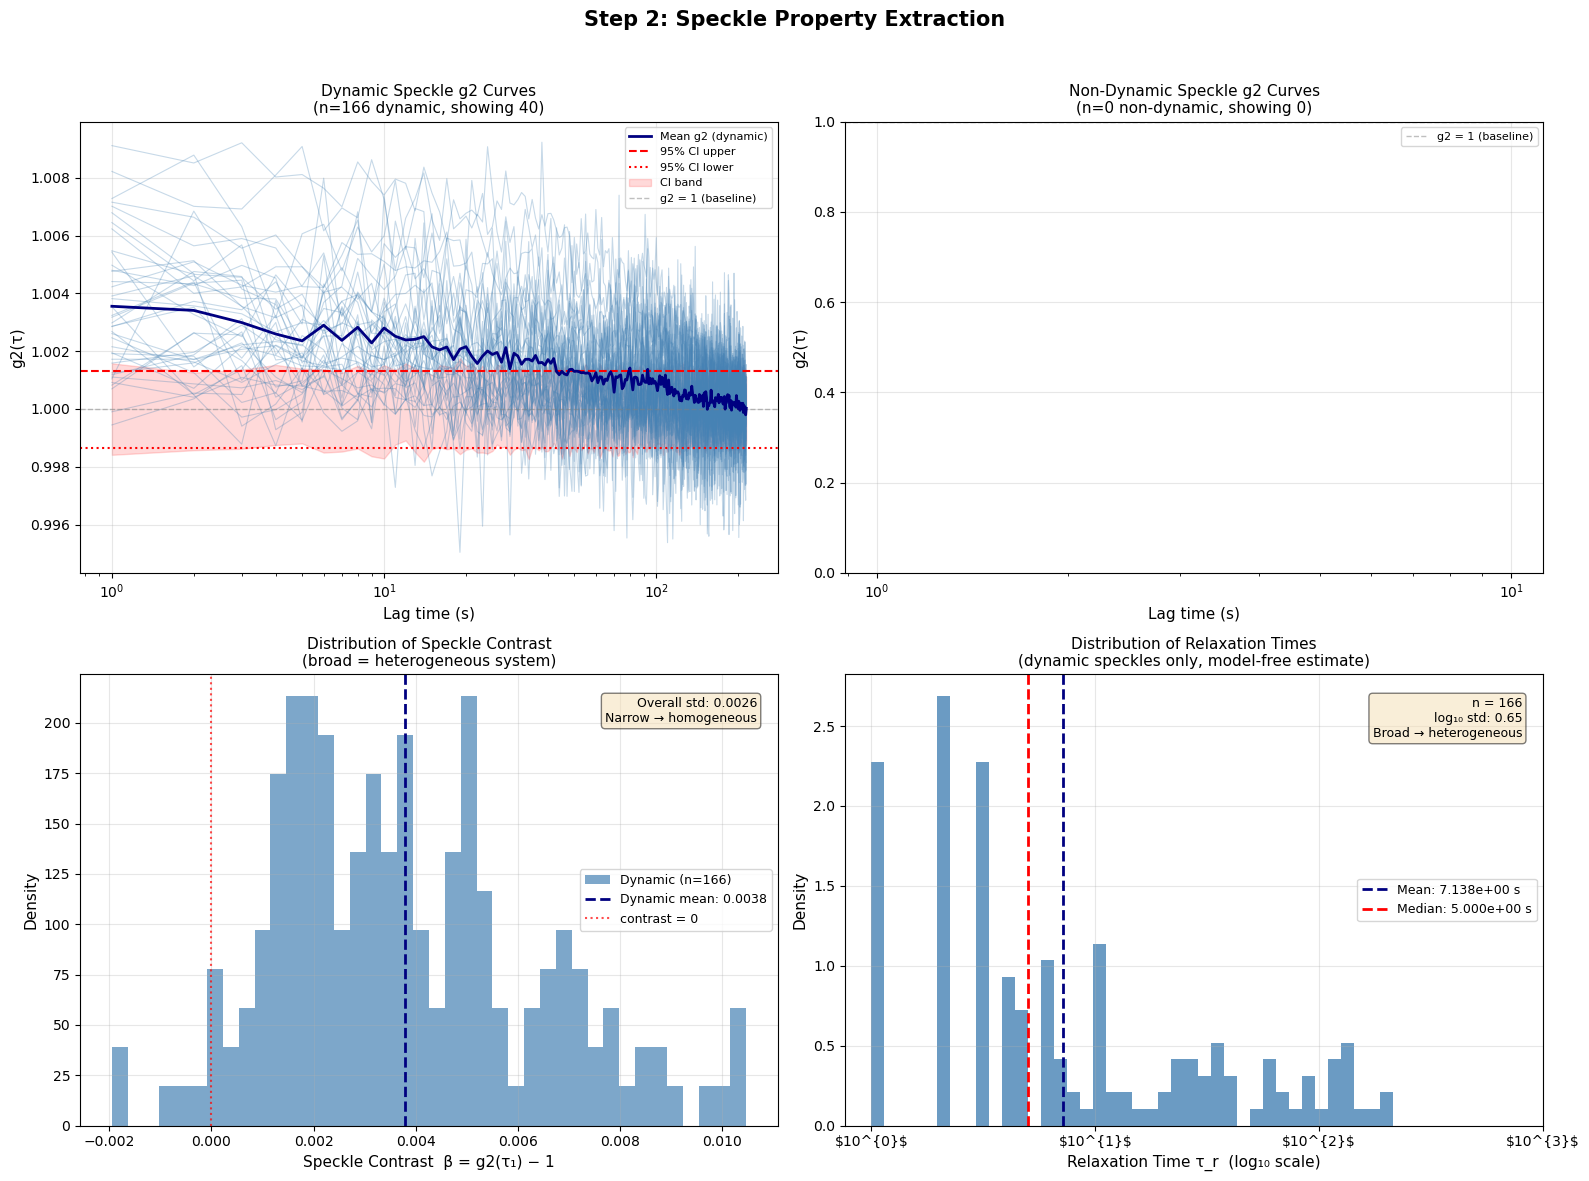


Figure saved as 'step2_speckle_properties.png'


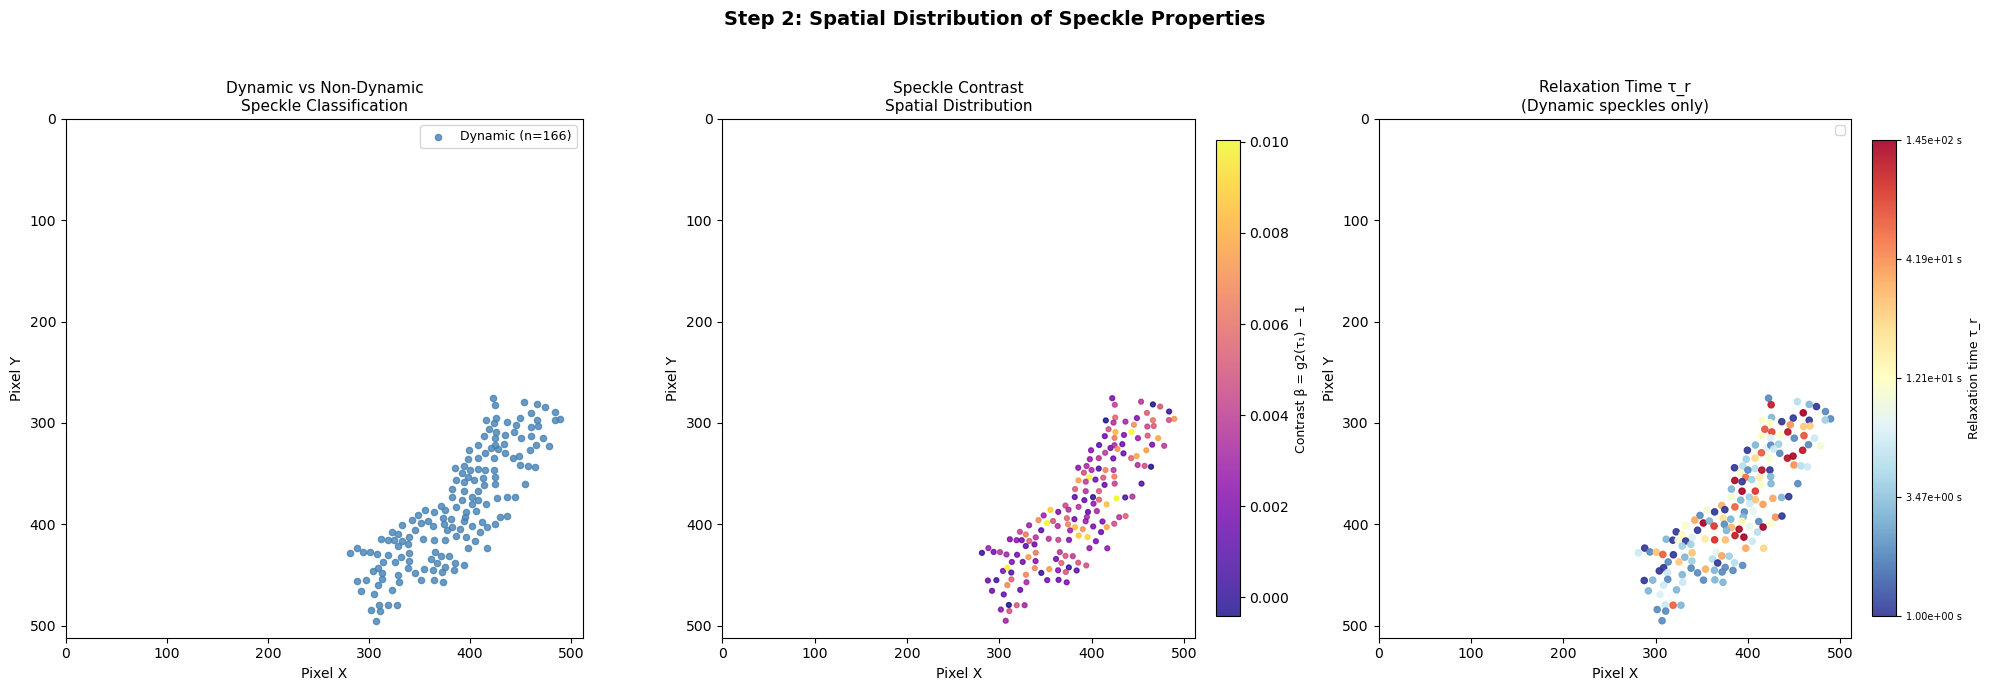


Figure saved as 'step2_speckle_map.png'

--- Saving Step 2 outputs ---
  Speckle properties saved -> step2_speckle_properties.csv
  g2 curves saved         -> step2_g2_curves.npz
  Summary saved           -> step2_summary.txt

--- Central Speckle DataFrame (first 10 rows) ---
 speckle_id  centroid_x  centroid_y  n_pixels  mean_intensity  contrast  is_dynamic  mean_g2_short  mean_g2_intermed  relaxation_time
          3  422.333333  275.600000        30        5.446698  0.001870        True       1.000960          1.000102              2.0
          6  453.629630  279.037037        27        5.563671  0.003633        True       1.001700          1.000351              5.0
         10  425.120000  282.080000        25        4.872168  0.004227        True       1.004416          1.003127            112.0
         12  466.375000  281.750000         8        4.343531 -0.001949        True       1.001619          0.999894              3.0
         15  474.222222  283.888889         9       

In [25]:

# ------------------------------------------------------------------ #
# Plot g2 curves, contrast and relaxation time distributions #
# ------------------------------------------------------------------ #
speckle_g2.plot_step2_results(
    speckle_props_df,
    g2_data,
    dt=DT,
    max_curves=40,
    ci_level=CI_LEVEL,
    figure_path='step2_speckle_properties.png'
)

# ------------------------------------------------------------------ #
# Plot spatial maps on detector                              #
# ------------------------------------------------------------------ #
speckle_g2.plot_speckle_map(
    speckle_props_df,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
    full_image=full_image,
    figure_path='step2_speckle_map.png'
)

# ------------------------------------------------------------------ #
# Save all outputs for Step 3                                #
# ------------------------------------------------------------------ #
print("\n--- Saving Step 2 outputs ---")
speckle_g2.save_step2_outputs(
    speckle_props_df,
    g2_data,
    output_prefix='step2'
)

# ------------------------------------------------------------------ #
#  Quick diagnostic print of the central DataFrame            #
# ------------------------------------------------------------------ #
print("\n--- Central Speckle DataFrame (first 10 rows) ---")
display_cols = ['speckle_id', 'centroid_x', 'centroid_y',
                'n_pixels', 'mean_intensity', 'contrast',
                'is_dynamic', 'mean_g2_short',
                'mean_g2_intermed', 'relaxation_time']
print(speckle_props_df[display_cols].head(10).to_string(index=False))

print("\n--- DataFrame dtypes ---")
print(speckle_props_df.dtypes)

print("\n--- DataFrame describe ---")
print(speckle_props_df[['mean_intensity', 'contrast',
                         'mean_g2_short', 'mean_g2_intermed',
                         'relaxation_time',
                         'n_above_ci']].describe().round(4))

# ------------------------------------------------------------------ #
# Final summary                                              #
# ------------------------------------------------------------------ #
n_total   = len(speckle_props_df)
n_dynamic = int(speckle_props_df['is_dynamic'].sum())
dyn_df    = speckle_props_df[
    speckle_props_df['is_dynamic'] &
    speckle_props_df['relaxation_time'].notna() &
    np.isfinite(speckle_props_df['relaxation_time'])]

print("\n" + "=" * 55)
print("STEP 2 COMPLETE")
print("=" * 55)
print(f"  Total speckle objects    : {n_total}")
print(f"  Dynamic speckles         : {n_dynamic} "
      f"({100*n_dynamic/n_total:.1f}%)"
      if n_total > 0 else
      f"  Dynamic speckles         : 0")
print(f"  Non-dynamic speckles     : {n_total - n_dynamic}")
print(f"\n  Contrast (β)")
print(f"    Mean  : "
      f"{speckle_props_df['contrast'].mean():.4f}")
print(f"    Std   : "
      f"{speckle_props_df['contrast'].std():.4f}")
print(f"    Range : "
      f"{speckle_props_df['contrast'].min():.4f} to "
      f"{speckle_props_df['contrast'].max():.4f}")

if len(dyn_df) > 0:
    print(f"\n  Relaxation time τ_r (dynamic speckles)")
    print(f"    n with finite τ_r : {len(dyn_df)}")
    print(f"    Mean   : "
          f"{dyn_df['relaxation_time'].mean():.3e} s")
    print(f"    Median : "
          f"{dyn_df['relaxation_time'].median():.3e} s")
    print(f"    Std    : "
          f"{dyn_df['relaxation_time'].std():.3e} s")
    print(f"    Range  : "
          f"{dyn_df['relaxation_time'].min():.3e} to "
          f"{dyn_df['relaxation_time'].max():.3e} s")
else:
    print(f"\n  No dynamic speckles with finite τ_r found.")
    print(f"  Consider:")
    print(f"    - Reducing SHORT_LAG_FRAC (currently "
          f"{SHORT_LAG_FRAC})")
    print(f"    - Reducing N_BOOTSTRAP to check if CI is too wide")
    print(f"    - Checking that DT is correct for your data")

print(f"\n  Output files:")
print(f"    step2_speckle_properties.csv")
print(f"    step2_g2_curves.npz")
print(f"    step2_summary.txt")
print(f"    step2_speckle_properties.png")
print(f"    step2_speckle_map.png")
print(f"\n  speckle_props_df is ready for Step 3.")
print("=" * 55)

## **Step 3: Dynamic Clustering & Heterogeneity Mapping**

In [26]:
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

In [27]:
# ============================================================ #
# PARAMETERS — Step 3: Clustering                              #
# ============================================================ #
IMAGE_HEIGHT = 512
IMAGE_WIDTH  = 512

# Feature extraction parameters
SHORT_LAG_FRAC   = 0.1
DECAY_LAG_FRAC   = (0.05, 0.5)
LONG_LAG_FRAC    = (0.5,  1.0)

# GMM parameters
GMM_N_RANGE      = range(2, 6)   # try 2 to 5 components
GMM_N_INIT       = 20
GMM_RANDOM_STATE = 42

# DBSCAN parameters
DBSCAN_EPS         = None        # None = auto-estimate
DBSCAN_MIN_SAMPLES = 3

# Output
CLUSTER_COL  = 'gmm_cluster'     # column used for map coloring

Reusing speckle_props_df and g2_data from Step 2.

--- Building feature matrix ---
  Dynamic speckles available : 166
  Final feature matrix     : 166 speckles x 5 features

  Feature summary:
       contrast  mean_g2_decay  mean_g2_long  slope_decay  relax_time
count  166.0000       166.0000      166.0000     166.0000    166.0000
mean     0.0038         1.0015        1.0004      -0.0000     23.4940
std      0.0026         0.0015        0.0008       0.0000     41.2076
min     -0.0019         0.9998        0.9993      -0.0001      1.0000
25%      0.0019         1.0004        0.9999      -0.0000      2.0000
50%      0.0034         1.0010        1.0002      -0.0000      5.0000
75%      0.0053         1.0019        1.0009      -0.0000     24.7500
max      0.0105         1.0074        1.0039       0.0000    214.0000

  Feature scaling (StandardScaler):
    contrast             : mean=0.0038  std=0.0025
    mean_g2_decay        : mean=1.0015  std=0.0015
    mean_g2_long         : mean=1.0004

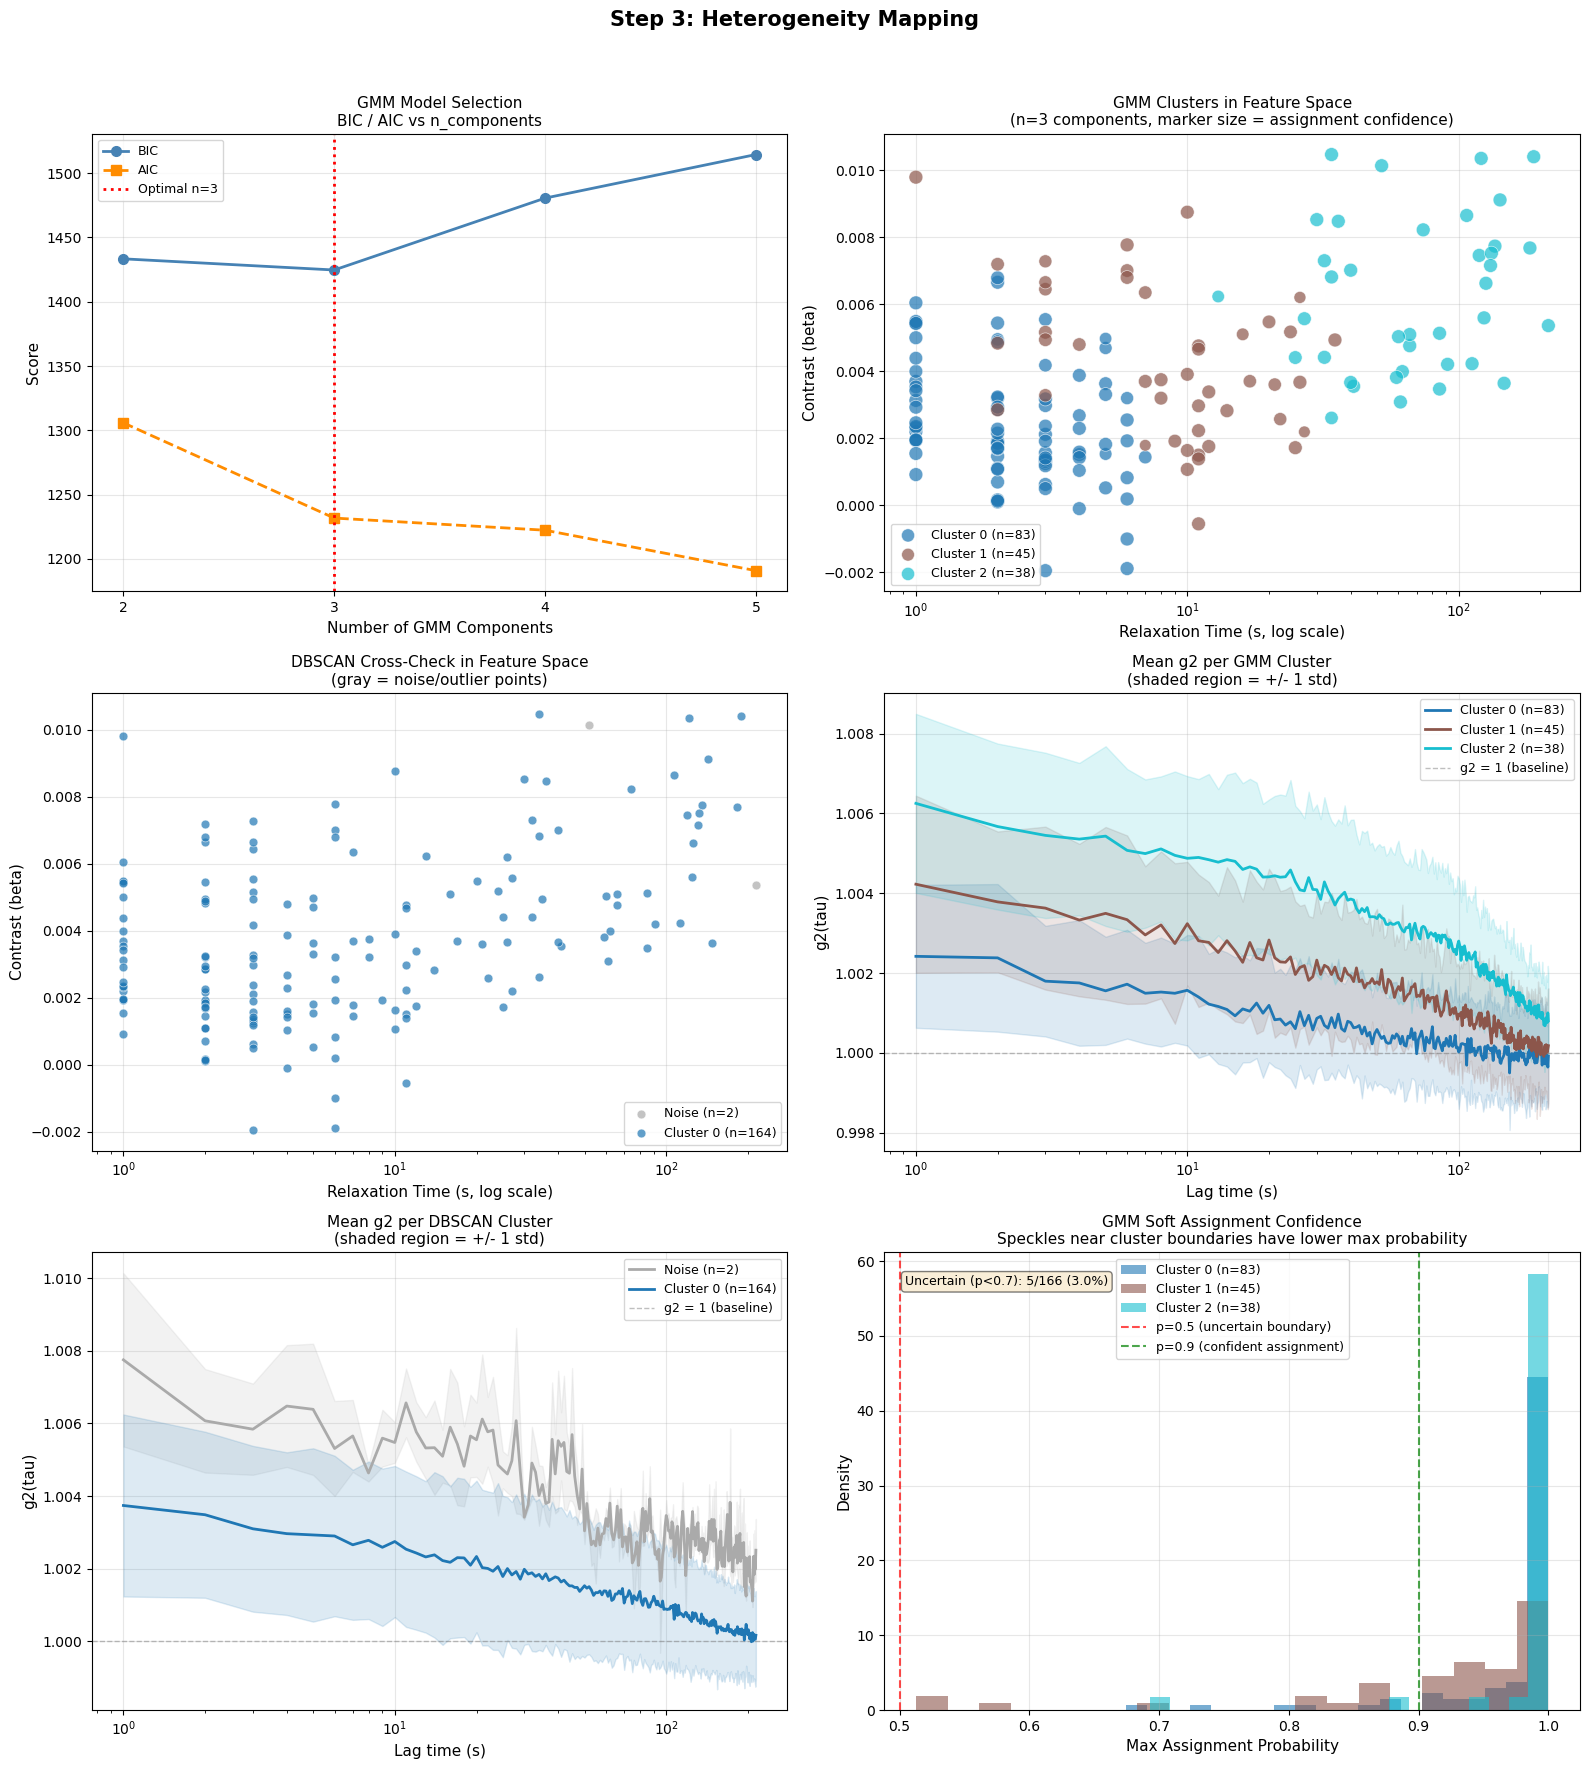


Figure saved as 'step3_heterogeneity.png'


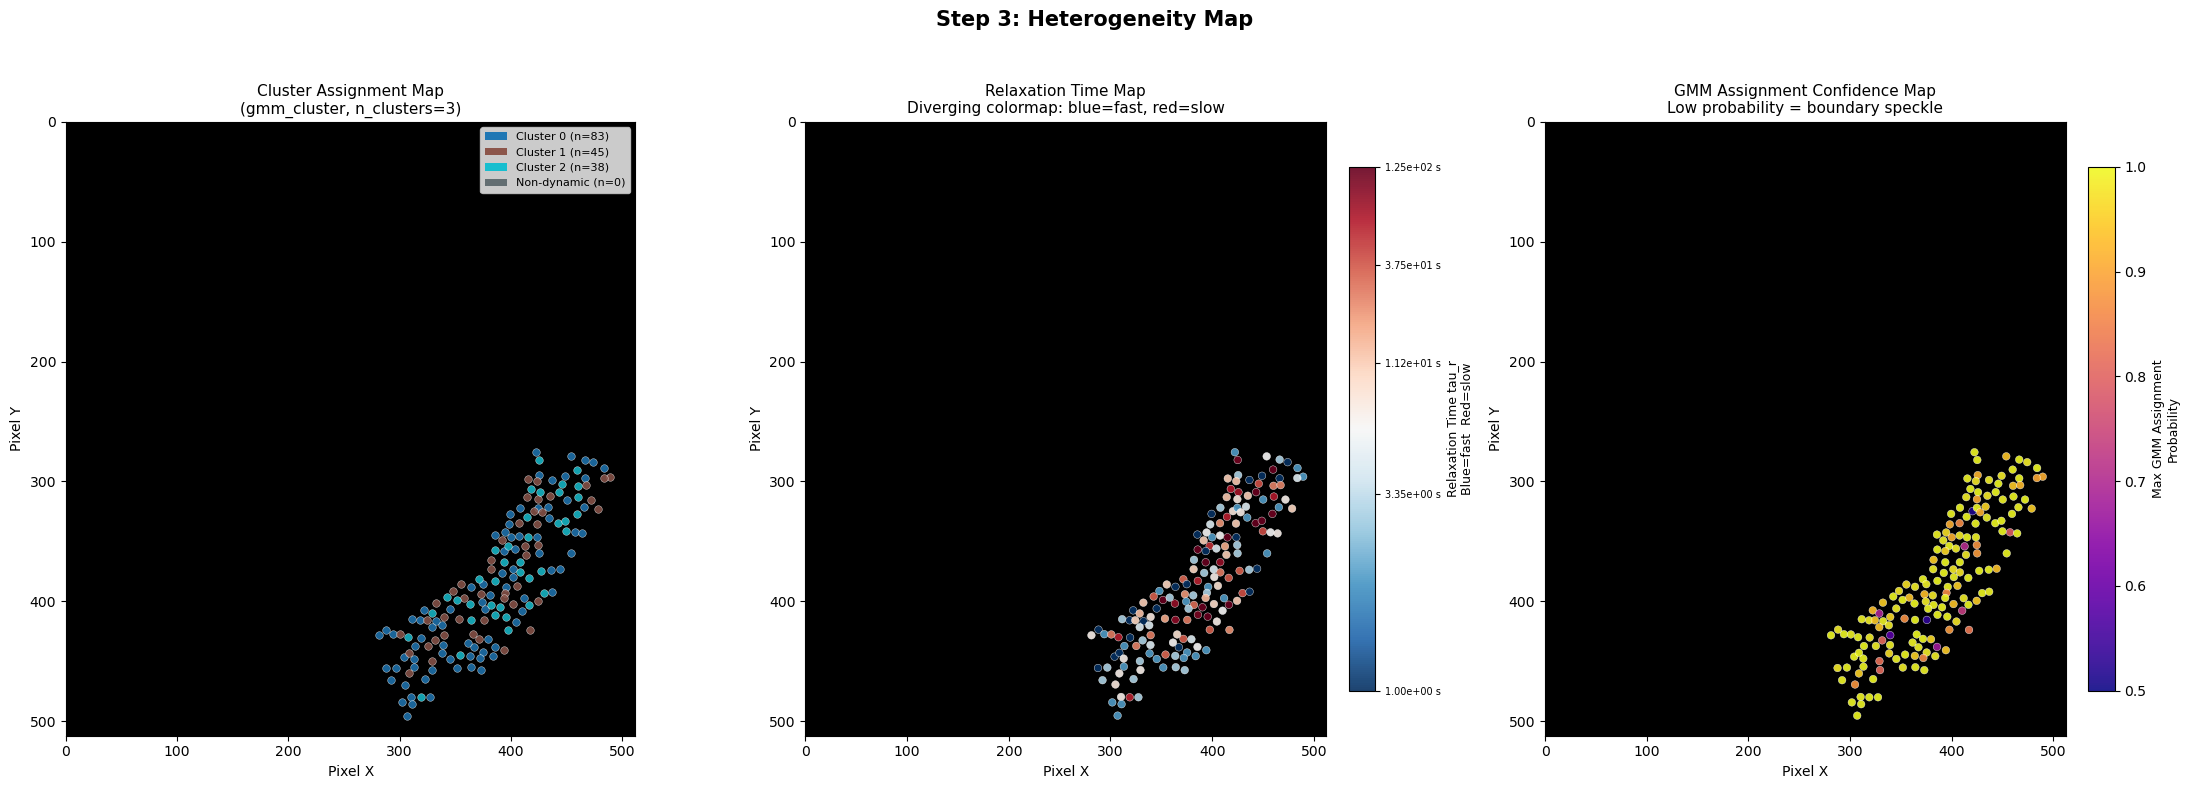


Figure saved as 'step3_heterogeneity_map.png'

--- Saving Step 3 outputs ---
  Feature matrix saved    -> step3_features.csv
  Cluster ACFs saved      -> step3_cluster_acfs.npz
  Summary saved           -> step3_summary.txt

--- Feature DataFrame (first 10 rows) ---
 speckle_id  centroid_x  centroid_y  contrast  mean_g2_decay  mean_g2_long   slope_decay  relax_time  gmm_cluster  gmm_max_prob  dbscan_cluster
          3  422.333333  275.600000  0.001870       1.000198      0.999848 -7.441271e-06         2.0            0      0.997162               0
          6  453.629630  279.037037  0.003633       1.000450      1.000441 -1.559142e-05         5.0            0      0.941086               0
         10  425.120000  282.080000  0.004227       1.003270      1.001249 -2.010312e-05       112.0            2      1.000000               0
         12  466.375000  281.750000 -0.001949       1.000023      0.999835 -1.514130e-05         3.0            0      0.999998               0
         15 

In [28]:


# ------------------------------------------------------------------ #
# Load from Step 2                                                    #
# ------------------------------------------------------------------ #
try:
    _ = speckle_props_df
    _ = g2_data
    print("Reusing speckle_props_df and g2_data from Step 2.")
except NameError:
    print("Loading speckle_props_df from file...")
    speckle_props_df = pd.read_csv(
        'step2_speckle_properties.csv')
    print("  Note: g2_data must be available in memory.")
    print("  Re-run Step 2 or reload g2_data from "
          "step2_g2_curves.npz before continuing.")
    raise RuntimeError(
        "g2_data dict must be available in memory. "
        "Re-run Step 2.")

# ------------------------------------------------------------------ #
# Build and scale feature matrix                             #
# ------------------------------------------------------------------ #
feature_df, feature_names = clustering.build_feature_matrix(
    speckle_props_df,
    g2_data,
    short_lag_frac=SHORT_LAG_FRAC,
    decay_lag_frac=DECAY_LAG_FRAC,
    long_lag_frac=LONG_LAG_FRAC
)

X_scaled, scaler = clustering.scale_features(feature_df, feature_names)

# ------------------------------------------------------------------ #
# GMM clustering with BIC selection                         #
# ------------------------------------------------------------------ #
best_gmm, best_n, bic_scores, aic_scores, \
    all_gmms, n_range = clustering.run_gmm_bic(
        X_scaled,
        n_components_range=GMM_N_RANGE,
        n_init=GMM_N_INIT,
        random_state=GMM_RANDOM_STATE
    )

feature_df = clustering.assign_gmm_clusters(
    feature_df, X_scaled, best_gmm)

# ------------------------------------------------------------------ #
# DBSCAN cross-check                                        #
# ------------------------------------------------------------------ #
feature_df, eps_used = clustering.run_dbscan(
    X_scaled,
    feature_df,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES
)

# ------------------------------------------------------------------ #
# Mean g2 per cluster                                       #
# ------------------------------------------------------------------ #
cluster_acfs_gmm = clustering.compute_cluster_mean_acf(
    feature_df, g2_data,
    cluster_col='gmm_cluster'
)

cluster_acfs_dbscan = clustering.compute_cluster_mean_acf(
    feature_df, g2_data,
    cluster_col='dbscan_cluster'
)

# ------------------------------------------------------------------ #
# Plot Step 3 results                                       #
# ------------------------------------------------------------------ #
clustering.plot_step3_results(
    feature_df, g2_data,
    bic_scores, aic_scores, n_range,
    cluster_acfs_gmm,
    cluster_acfs_dbscan,
    best_n,
    figure_path='step3_heterogeneity.png'
)




# ------------------------------------------------------------------ #
# Heterogeneity map                                         #
# ------------------------------------------------------------------ #
clustering.plot_heterogeneity_map(
    feature_df,
    speckle_props_df,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
    full_image=None,
    cluster_col=CLUSTER_COL,
    figure_path='step3_heterogeneity_map.png'
)

# ------------------------------------------------------------------ #
# Save outputs                                               #
# ------------------------------------------------------------------ #
print("\n--- Saving Step 3 outputs ---")
clustering.save_step3_outputs(
    feature_df,
    cluster_acfs_gmm,
    cluster_acfs_dbscan,
    output_prefix='step3'
)

# ------------------------------------------------------------------ #
# Diagnostic print                                           #
# ------------------------------------------------------------------ #
print("\n--- Feature DataFrame (first 10 rows) ---")
display_cols = ['speckle_id', 'centroid_x', 'centroid_y',
                'contrast', 'mean_g2_decay', 'mean_g2_long',
                'slope_decay', 'relax_time',
                'gmm_cluster', 'gmm_max_prob',
                'dbscan_cluster']
print(feature_df[display_cols].head(10).to_string(index=False))

# ------------------------------------------------------------------ #
# Final summary                                              #
# ------------------------------------------------------------------ #
n_dynamic  = len(feature_df)
gmm_labels = sorted(feature_df['gmm_cluster'].unique())

print("\n" + "=" * 55)
print("STEP 3 COMPLETE")
print("=" * 55)
print(f"  Dynamic speckles clustered : {n_dynamic}")
print(f"  Optimal GMM components     : {best_n}")
print(f"  DBSCAN eps used            : {eps_used:.4f}")

print(f"\n  GMM Cluster Summary "
      f"(ordered by mean relax_time):")
for k in gmm_labels:
    sub = feature_df[feature_df['gmm_cluster'] == k]
    print(f"    Cluster {k} : n={len(sub):4d}  "
          f"relax_time={sub['relax_time'].mean():.3e} s  "
          f"contrast={sub['contrast'].mean():.4f}  "
          f"mean_prob={sub['gmm_max_prob'].mean():.3f}")

n_uncertain = int(np.sum(
    feature_df['gmm_max_prob'] < 0.7))
print(f"\n  Uncertain assignments (p<0.7) : "
      f"{n_uncertain} "
      f"({100*n_uncertain/n_dynamic:.1f}%)")

dbscan_labels = sorted(feature_df['dbscan_cluster'].unique())
n_noise = int(np.sum(feature_df['dbscan_cluster'] == -1))
n_db_clusters = len([k for k in dbscan_labels if k >= 0])
print(f"\n  DBSCAN found {n_db_clusters} clusters, "
      f"{n_noise} noise points "
      f"({100*n_noise/n_dynamic:.1f}%)")

print(f"\n  Output files:")
print(f"    step3_features.csv")
print(f"    step3_cluster_acfs.npz")
print(f"    step3_summary.txt")
print(f"    step3_heterogeneity.png")
print(f"    step3_heterogeneity_map.png")
print(f"\n  feature_df is ready for Step 4.")
print("=" * 55)

## **Step 4: Fitting To Stretched Exponential Model**

In [29]:
# Merge gmm_cluster labels from feature_df into speckle_props_df
# Keep all rows in speckle_props_df (left join) in case feature_df
# only contains dynamic speckles
cols_to_merge = ['speckle_id', 'gmm_cluster', 'gmm_max_prob',
                 'gmm_prob_0', 'gmm_prob_1', 'gmm_prob_2']

# Only take columns that actually exist in feature_df
cols_to_merge = [c for c in cols_to_merge 
                 if c in feature_df.columns or c == 'speckle_id']

speckle_props_df = speckle_props_df.merge(
    feature_df[cols_to_merge],
    on='speckle_id',
    how='left'
)

# Non-dynamic speckles will have NaN for gmm_cluster
# Fill with -1 to indicate unclassified
speckle_props_df['gmm_cluster'] = (
    speckle_props_df['gmm_cluster'].fillna(-1).astype(int)
)

print(speckle_props_df.columns.tolist())
print(speckle_props_df['gmm_cluster'].value_counts().sort_index())

['speckle_id', 'centroid_x', 'centroid_y', 'n_pixels', 'mean_intensity', 'contrast', 'is_dynamic', 'mean_g2_short', 'mean_g2_intermed', 'relaxation_lag', 'relaxation_time', 'n_above_ci', 'n_lags', 'max_lag_time', 'gmm_cluster', 'gmm_max_prob', 'gmm_prob_0', 'gmm_prob_1', 'gmm_prob_2']
gmm_cluster
0    83
1    45
2    38
Name: count, dtype: int64


###  KWW Stretched Exponential Fitting; $g_2(\tau) = 1 + \beta \, exp[-2(\tau/\tau_r)^{\gamma}]$ 

In [30]:
# ============================================================ #
# KWW Stretched Exponential Fitting                                        #
# ============================================================ #

print("\n" + "="*60)
print("STEP 4: KWW FITTING TO CLUSTER-AVERAGED g2")
print("="*60)

# Fit KWW to all clusters
kww_results, cluster_g2 = fitting.fit_kww_all_clusters(
    speckle_props_df,
    g2_data,
    dt=DT,
    max_lag=MAX_LAG
)



STEP 4: KWW FITTING TO CLUSTER-AVERAGED g2

--- KWW Fitting by GMM Cluster ---

  Cluster 0:
    Speckles averaged : 83
    Lag range         : 1.0000 - 213.0000 s
    beta      : 0.002 +/- 0.000
    tau_r     : 70.0194 +/- 3.0245 s
    gamma     : 0.894 +/- 0.067
    R²        : 0.8869
    chi2_red  : 1.3473

  Cluster 1:
    Speckles averaged : 45
    Lag range         : 1.0000 - 213.0000 s
    beta      : 0.003 +/- 0.000
    tau_r     : 156.4848 +/- 3.1494 s
    gamma     : 1.124 +/- 0.054
    R²        : 0.9479
    chi2_red  : 0.8846

  Cluster 2:
    Speckles averaged : 38
    Lag range         : 1.0000 - 213.0000 s
    beta      : 0.005 +/- 0.000
    tau_r     : 241.1776 +/- 3.5215 s
    gamma     : 1.146 +/- 0.043
    R²        : 0.9804
    chi2_red  : 0.4724


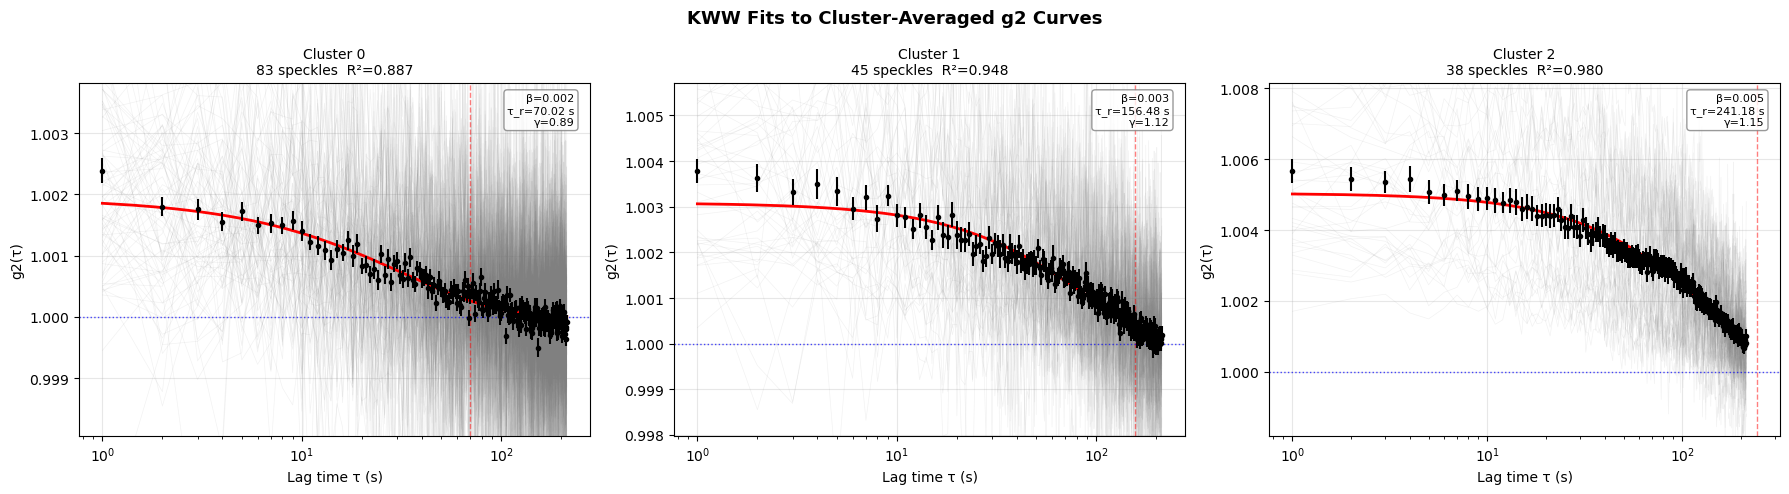

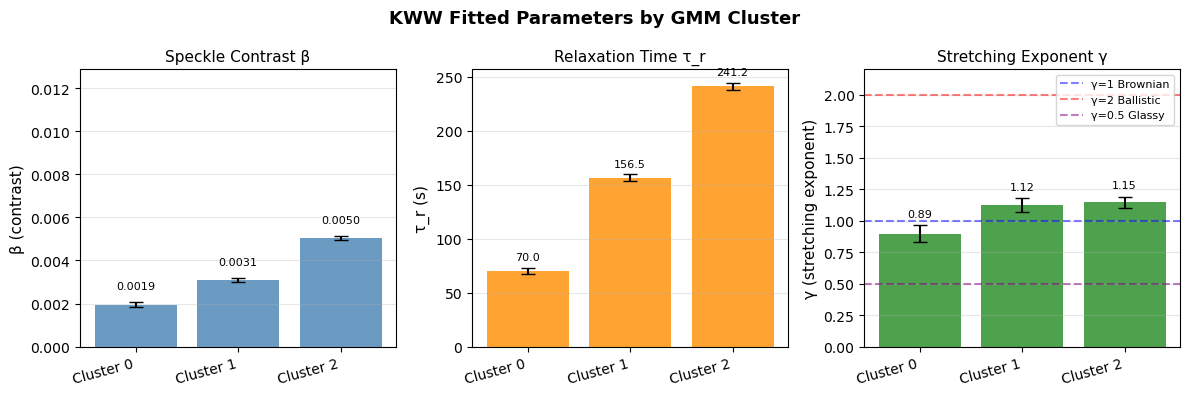

In [31]:
# Plot g2 curves with fits
fig_kww = fitting.plot_kww_fits(cluster_g2, kww_results, dt=DT)

# Plot summary of fitted parameters
fig_summary = fitting.plot_kww_summary(kww_results)
